In [1]:
# Base imports
import os
import pickle

# Compute imports
import numpy as np
import pandas as pd

import scipy
from scipy import spatial as sp
from scipy.spatial.distance import squareform
from scipy.sparse import csr_matrix
from scipy.cluster import hierarchy as hc
from scipy.cluster.hierarchy import cophenet


from tqdm.notebook import tqdm, trange

# Plotting imports
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
from matplotlib import pyplot as plt
import seaborn as sns
from plotly import express as px

# ML import
from sklearn.decomposition import NMF
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, median_absolute_error
from sklearn.mixture import GaussianMixture
from pyphylon.util import load_config

import plotly.io as pio
pio.renderers.default = 'iframe'

from pyphylon.pangenome import get_gene_frequency_submatrices, connectivity
from pyphylon.models import run_nmf, normalize_nmf_outputs, binarize_nmf_outputs, generate_nmf_reconstructions, calculate_nmf_reconstruction_metrics

```
python optNMF.py --csv /mnt/craig/pan_phylon/P_aeruginosa/data/processed_ncbi/panaroo_results/CAR_genomes/df_acc.csv --index-col 0 --seeds 0,1,42 --ranks 4:100:1 --beta-loss frobenius --max-iter 7500 --x-binarize-L kmeans --x-binarize-A kmeans --corr-threshold 0.7 --make-sankey --outdir /mnt/craig/pan_phylon/P_aeruginosa/data/processed_ncbi/nmf-outputs/opt_nmf --name paeruginosa --n-jobs 40 --threads-per-job 1
```

In [2]:
df_genes = pd.read_csv('/mnt/craig/pan_phylon/P_aeruginosa/data/processed_ncbi/panaroo_results/gene_presence_absence.Rtab', sep = '\t').set_index('Gene')

display(
    df_genes.shape,
    df_genes.head()
)

(43601, 1317)

,GCA_048593205.1,GCA_051016185.1,GCF_000006765.1,GCF_000014625.1,GCF_000026645.1,GCF_000168335.1,GCF_000223945.1,GCF_000223965.1,GCF_000226155.1,GCF_000271365.1,...,GCF_902172305.2,GCF_902703185.1,GCF_902703195.1,GCF_902703215.1,GCF_904866275.1,GCF_905071885.1,GCF_951691365.1,GCF_951802375.2,GCF_951805275.2,GCF_976988945.1
Gene,,,,,,,,,,,,,,,,,,,,,
rpsK,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
group_38282,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
group_38069,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
arfA,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
rpmG,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


In [3]:
metadata = pd.read_csv('/mnt/craig/pan_phylon/P_aeruginosa/data/interim/2d_ncbi_enriched_metadata.csv', index_col=0, dtype='object')
metadata

,genome_id,genome_name,organism_name,taxon_id,genome_status,strain,culture_collection,type_strain,completion_date,bioproject_accession,...,organism_infraspecific_names_strain,organism_infraspecific_names_isolate,assembly_stats_total_number_of_chromosomes,wgs_project_accession,annotation_count_gene_total,annotation_count_gene_protein_coding,annotation_count_gene_pseudogene,mash_cluster,mlst_source,mlst
0,GCA_048593205.1,Pseudomonas aeruginosa ps1,Pseudomonas aeruginosa,287,Complete,ps1,NaN,NaN,2025-03-17,PRJNA1226941,...,ps1,NaN,1.0,NaN,5601.0,5416.0,121.0,62,-,-
1,GCA_051016185.1,Pseudomonas aeruginosa 25181,Pseudomonas aeruginosa,287,Complete,25181,NaN,NaN,2025-06-21,PRJNA1180571,...,25181,NaN,2.0,NaN,7102.0,6922.0,95.0,2,PubMLST,253
2,GCF_000006765.1,Pseudomonas aeruginosa PAO1,Pseudomonas aeruginosa PAO1,208964,Complete,PAO1,NaN,NaN,2006-07-24,PRJNA331,...,PAO1,NaN,1.0,NaN,5697.0,5572.0,19.0,34,-,-
3,GCF_000014625.1,Pseudomonas aeruginosa UCBPP-PA14,Pseudomonas aeruginosa UCBPP-PA14,208963,Complete,UCBPP-PA14,NaN,NaN,2006-10-06,PRJNA386,...,UCBPP-PA14,NaN,1.0,NaN,6041.0,5891.0,70.0,2,PubMLST,253
4,GCF_000026645.1,Pseudomonas aeruginosa LESB58,Pseudomonas aeruginosa LESB58,557722,Complete,LESB58,NaN,NaN,2008-12-24,PRJEA31101,...,LESB58,NaN,1.0,NaN,6195.0,6059.0,52.0,94,PubMLST,146
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1312,GCF_905071885.1,Pseudomonas aeruginosa MINF_3A,Pseudomonas aeruginosa,287,Complete,MINF_3A,NaN,NaN,2020-11-19,PRJNA646837,...,MINF_3A,MINF_3A,1.0,NaN,6490.0,6344.0,64.0,11,PubMLST,357
1313,GCF_951691365.1,Pseudomonas aeruginosa 4782MK,Pseudomonas aeruginosa,287,Complete,4782MK,NaN,NaN,2023-06-13,PRJEB62425,...,4782MK,4782MK,3.0,NaN,7094.0,6911.0,106.0,35,PubMLST,233
1314,GCF_951802375.2,Pseudomonas aeruginosa 3541,Pseudomonas aeruginosa,287,Complete,3541,NaN,NaN,2023-06-13,PRJEB62425,...,3541,3541,3.0,NaN,6631.0,6467.0,82.0,101,PubMLST,621
1315,GCF_951805275.2,Pseudomonas aeruginosa 3796A,Pseudomonas aeruginosa,287,Complete,3796A,NaN,NaN,2023-06-13,PRJEB62425,...,3796A,3796A,2.0,NaN,6731.0,6564.0,86.0,101,PubMLST,621


In [4]:
# Filter metadata for Complete sequences only
metadata_complete = metadata

# # Filter P matrix for Complete sequences only
df_genes_complete = df_genes
inCompleteseqs = df_genes_complete.sum(axis=1) > 0 # filter for genes found in complete sequences
df_genes_complete = df_genes_complete[inCompleteseqs]

df_genes_complete.shape

(43601, 1317)

In [5]:
# Get sparse representations of the P matrix
df_genes_complete_sparse = df_genes_complete.astype(pd.SparseDtype("int8", 0))

coo_genes = df_genes_complete_sparse.sparse.to_coo()
csr_genes = csr_matrix(coo_genes)
csr_genes

<43601x1317 sparse matrix of type '<class 'numpy.int8'>'
	with 8100025 stored elements in Compressed Sparse Row format>

In [6]:
# Convert sparse P matrix into a frequency matrix
df_genes_freq = pd.DataFrame(index=df_genes_complete_sparse.index, data=csr_genes.sum(axis=1), columns=['freq'])
df_genes_freq = df_genes_freq.freq
df_genes_freq.sort_values()

Gene
group_0           1
group_22072       1
group_22073       1
group_22105       1
group_22108       1
               ... 
group_16543    1317
gmhA           1317
group_16544    1317
nth            1317
rpsK           1317
Name: freq, Length: 43601, dtype: int64

In [7]:
# Import (full) accessory genome
df_acc_complete = pd.read_csv('/mnt/craig/pan_phylon/P_aeruginosa/data/processed_ncbi/panaroo_results//CAR_genomes/df_acc.csv', index_col=0)
df_acc_complete

,GCA_048593205.1,GCA_051016185.1,GCF_000006765.1,GCF_000014625.1,GCF_000026645.1,GCF_000168335.1,GCF_000223945.1,GCF_000223965.1,GCF_000226155.1,GCF_000271365.1,...,GCF_902172305.2,GCF_902703185.1,GCF_902703195.1,GCF_902703215.1,GCF_904866275.1,GCF_905071885.1,GCF_951691365.1,GCF_951802375.2,GCF_951805275.2,GCF_976988945.1
Gene,,,,,,,,,,,,,,,,,,,,,
group_35823,0,0,0,0,1,0,0,0,0,1,...,0,0,0,0,0,1,1,0,1,0
group_22295,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,1,1,0,0,0
group_14781,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
gatA,0,0,1,0,0,1,0,0,0,0,...,0,1,0,0,1,0,1,0,0,0
group_33975,0,1,0,0,0,1,1,1,0,0,...,0,0,0,0,0,0,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cas1f,0,1,0,1,0,1,0,0,1,1,...,0,0,0,0,1,1,1,1,1,0
group_32366,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
group_18075,0,0,0,0,1,0,1,1,1,0,...,0,0,0,1,1,0,1,0,0,0


In [8]:
# Find cutoff frequency between accessory & rare genomes
acc_min_freq = 100 * df_acc_complete.sum(axis=1).min() / df_genes_complete.shape[1]
acc_min_freq

8.883826879271071

In [9]:
# Find cutoff frequency between accessory & core genomes
acc_max_freq = 100 * df_acc_complete.sum(axis=1).max() / df_genes_complete.shape[1]
acc_max_freq

98.78511769172361

## Reduced accessory genome (min to 75%)

In [10]:
cond1 = df_genes_freq >= acc_min_freq
cond2 = df_genes_freq <= df_acc_complete.shape[1] * 0.75

df_acc_75 = df_genes_complete.loc[df_genes_freq[cond1 & cond2].sort_values().index]
df_acc_75

,GCA_048593205.1,GCA_051016185.1,GCF_000006765.1,GCF_000014625.1,GCF_000026645.1,GCF_000168335.1,GCF_000223945.1,GCF_000223965.1,GCF_000226155.1,GCF_000271365.1,...,GCF_902172305.2,GCF_902703185.1,GCF_902703195.1,GCF_902703215.1,GCF_904866275.1,GCF_905071885.1,GCF_951691365.1,GCF_951802375.2,GCF_951805275.2,GCF_976988945.1
Gene,,,,,,,,,,,,,,,,,,,,,
group_99,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
group_25627,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
group_25636,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
group_25779,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
group_25821,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
group_26855,1,0,0,0,1,1,1,1,0,0,...,1,1,1,0,1,1,1,1,1,1
group_32082,1,0,0,0,1,1,1,1,0,0,...,1,1,1,0,1,1,1,1,1,1
group_23565,1,0,0,0,1,1,1,1,0,0,...,1,1,1,0,1,1,1,0,0,1


## Infrequent accessory genome (min to 50%)

In [11]:
cond1 = df_genes_freq >= acc_min_freq
cond2 = df_genes_freq <= df_acc_complete.shape[1] * 0.5

df_acc_50 = df_genes_complete.loc[df_genes_freq[cond1 & cond2].sort_values().index]
df_acc_50

,GCA_048593205.1,GCA_051016185.1,GCF_000006765.1,GCF_000014625.1,GCF_000026645.1,GCF_000168335.1,GCF_000223945.1,GCF_000223965.1,GCF_000226155.1,GCF_000271365.1,...,GCF_902172305.2,GCF_902703185.1,GCF_902703195.1,GCF_902703215.1,GCF_904866275.1,GCF_905071885.1,GCF_951691365.1,GCF_951802375.2,GCF_951805275.2,GCF_976988945.1
Gene,,,,,,,,,,,,,,,,,,,,,
group_99,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
group_25627,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
group_25636,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
group_25779,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
group_25821,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
group_24638,0,1,1,1,1,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,1
group_19321,1,0,1,0,1,1,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
group_28803,1,0,0,0,1,1,0,0,1,1,...,1,1,1,0,1,0,1,0,0,1


## Sparse accessory genome (min to 25%)

In [12]:
cond1 = df_genes_freq >= acc_min_freq
cond2 = df_genes_freq <= df_acc_complete.shape[1] * 0.25

df_acc_25 = df_genes_complete.loc[df_genes_freq[cond1 & cond2].sort_values().index]
df_acc_25

,GCA_048593205.1,GCA_051016185.1,GCF_000006765.1,GCF_000014625.1,GCF_000026645.1,GCF_000168335.1,GCF_000223945.1,GCF_000223965.1,GCF_000226155.1,GCF_000271365.1,...,GCF_902172305.2,GCF_902703185.1,GCF_902703195.1,GCF_902703215.1,GCF_904866275.1,GCF_905071885.1,GCF_951691365.1,GCF_951802375.2,GCF_951805275.2,GCF_976988945.1
Gene,,,,,,,,,,,,,,,,,,,,,
group_99,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
group_25627,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
group_25636,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
group_25779,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
group_25821,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
group_33739,0,1,1,1,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
group_32487,0,1,0,1,0,0,0,0,0,0,...,1,0,1,0,0,0,0,0,0,0
group_33327,0,1,1,1,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1


# NMF decomposition

In [13]:
RANK = 28 # Enter your rank here (from optNMF output)

# Useful functions

In [14]:
# Util functions for consensus clustering (from Nimfa)
from operator import mul, eq, ne, add, ge, le, itemgetter
from operator import truediv as div

def argmax(X, axis=None):
    idxX = np.asmatrix(X).argmax(axis)
    if axis is None:
        eX = X[idxX // X.shape[1], idxX % X.shape[1]]
    elif axis == 0:
        eX = [X[idxX[0, idx], col]
              for idx, col in zip(range(X.shape[1]), range(X.shape[1]))]
    else:
        eX = [X[row, idxX[idx, 0]]
              for row, idx in zip(range(X.shape[0]), range(X.shape[0]))]
    return eX, idxX


def repmat(X, m, n):
    return np.tile(np.asmatrix(X), (m, n))


def elop(X, Y, op):
    try:
        zp1 = op(1, 0)
        zp2 = op(0, 0)
        zp = zp1 != 0 or zp2 != 0
    except:
        zp = 0
    
    try:
        X[X == 0] = np.finfo(X.dtype).eps
        Y[Y == 0] = np.finfo(Y.dtype).eps
    except ValueError:
        return op(np.mat(X), np.mat(Y))
    
    return op(np.mat(X), np.mat(Y))

In [15]:
def connectivity(X, H):
    """
    Compute the connectivity matrix for the samples based on their mixture coefficients. 
    
    The connectivity matrix C is a symmetric matrix which shows the shared membership of the samples: entry C_ij is 1 iff sample i and 
    sample j belong to the same cluster, 0 otherwise. Sample assignment is determined by its largest expression value. 
    
    Return connectivity matrix.
    
    :param idx: Used in the multiple NMF model. In factorizations following
        standard NMF model or nonsmooth NMF model ``idx`` is always None.
    :type idx: None or `str` with values 'coef' or 'coef1' (`int` value of 0 or 1, respectively) 
    """
    _, idx = argmax(H, axis=0)
    mat1 = repmat(idx, X.shape[1], 1)
    mat2 = repmat(idx.T, 1, X.shape[1])
    conn = elop(mat1, mat2, eq)
    
    return np.mat(conn, dtype='d')

## Consensus model 1: Full accessory genome

__Main model we will be working with__

In [16]:
# Input matrix
X = df_acc_complete

# Rank (determined by Mash)
rank = RANK

# Initialize DataFrame of error metrics (as list of dicts)
nmf_errors = []

# Initialize dict of low-dim representations (phylons)
W_dict = {}

# Initialize dict of corresponding affinities
H_dict = {}

# Perform NMF 50 times
for i in trange(3):
    # Initialize NMF object
    model = NMF(
        n_components=rank,
        init='nndsvd',
        max_iter=5_000,
        random_state=i
    )
    
    # Fit and transform the model
    W = model.fit_transform(X)
    H = model.components_

    # Typecast as DataFrames
    init_names = [f'phylon{i}' for i in range(rank)]
    W = pd.DataFrame(W, index=X.index, columns=init_names)
    H = pd.DataFrame(H, index=init_names, columns=X.columns)

    # Save matrices to respective dicts
    W_dict[i] = W
    H_dict[i] = H
    
    # Reconstruct matrix
    X_reconstructed = np.dot(W, H)
    X_diff = X - X_reconstructed
    
    # Calculate errors
    ssr = np.sum(X_diff**2, axis=0).sum(axis=0)
    frobenius = np.linalg.norm(X_diff, 'fro')
    
    mae = median_absolute_error(X, X_reconstructed)
    rmse = np.sqrt(mean_squared_error(X, X_reconstructed))
    
    # Save errors to DataFrame (as list of dicts)
    error = {}
    error['Run'] = i+1
    error['SSR'] = ssr
    error['Frobenius'] = frobenius
    error['MAE'] = mae
    error['RMSE'] = rmse
    
    nmf_errors.append(error)

# Typecast to DataFrame
df_nmf_errors = pd.DataFrame(nmf_errors).set_index('Run')

  0%|          | 0/3 [00:00<?, ?it/s]

In [17]:
# Initialize the new dictionary
conn_dict = {}

# Loop over each matrix in the H_dict dictionary
for key, H in H_dict.items():
    conn_dict[key] = connectivity(X.values, H.values)

In [18]:
# Consensus matrix for these runs (H matrix, default)
consensus_matrix = np.zeros(shape=conn_dict[0].shape)

for key, conn_matrix in conn_dict.items():
    consensus_matrix += conn_matrix

consensus_matrix /= len(conn_dict)

df_consensus_matrix = pd.DataFrame(consensus_matrix, index=X.columns, columns=X.columns)
df_consensus_matrix

,GCA_048593205.1,GCA_051016185.1,GCF_000006765.1,GCF_000014625.1,GCF_000026645.1,GCF_000168335.1,GCF_000223945.1,GCF_000223965.1,GCF_000226155.1,GCF_000271365.1,...,GCF_902172305.2,GCF_902703185.1,GCF_902703195.1,GCF_902703215.1,GCF_904866275.1,GCF_905071885.1,GCF_951691365.1,GCF_951802375.2,GCF_951805275.2,GCF_976988945.1
GCA_048593205.1,1.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,1.0,0.000000,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
GCA_051016185.1,0.0,1.0,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
GCF_000006765.1,0.0,0.0,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,1.000000,0.0,0.0,1.000000,1.000000,0.666667,0.0,0.0,0.0,0.0
GCF_000014625.1,0.0,1.0,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
GCF_000026645.1,0.0,0.0,0.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.333333,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GCF_905071885.1,0.0,0.0,0.666667,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.666667,0.0,0.0,0.666667,0.666667,1.000000,0.0,0.0,0.0,0.0
GCF_951691365.1,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,1.0,1.0,1.0,0.0
GCF_951802375.2,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,1.0,1.0,1.0,0.0
GCF_951805275.2,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,1.0,1.0,1.0,0.0


In [19]:
# change this to get different number of clusters

# Minimum acceptable value for robust clusters = 50%
thresh = 0.75

# change this to get a different linkage (by method)
df_consensus_dist = 1 - df_consensus_matrix
link = hc.linkage(scipy.spatial.distance.squareform(df_consensus_dist), method='ward')

# retrieve clusters using fcluster
dist = scipy.spatial.distance.squareform(df_consensus_dist)

consensus_clst = pd.DataFrame(index=X.columns)
consensus_clst['cluster'] = hc.fcluster(link, thresh * dist.max(), 'distance')

In [21]:
# Bar plot showing sizes of each consensus strain cluster (at thresh = 0.5)
px.bar(
    x=consensus_clst.cluster.value_counts().sort_index().index,
    y=consensus_clst.cluster.value_counts().sort_index().values
)

In [22]:
# Color each NMF cluster (default matplotlib colors)

cm = matplotlib.colormaps.get_cmap('tab20')
cmb = matplotlib.colormaps.get_cmap('tab20b')
cmc = matplotlib.colormaps.get_cmap('tab20c')
cm_colors = cm.colors + cmb.colors + cmc.colors

consensus_clr = dict(zip(sorted(consensus_clst.cluster.unique()), cm_colors))
consensus_clst['color'] = consensus_clst.cluster.map(consensus_clr)

print('Number of colors: ', len(consensus_clr))
print('Number of clusters', len(consensus_clst.cluster.unique()))

Number of colors:  45
Number of clusters 45


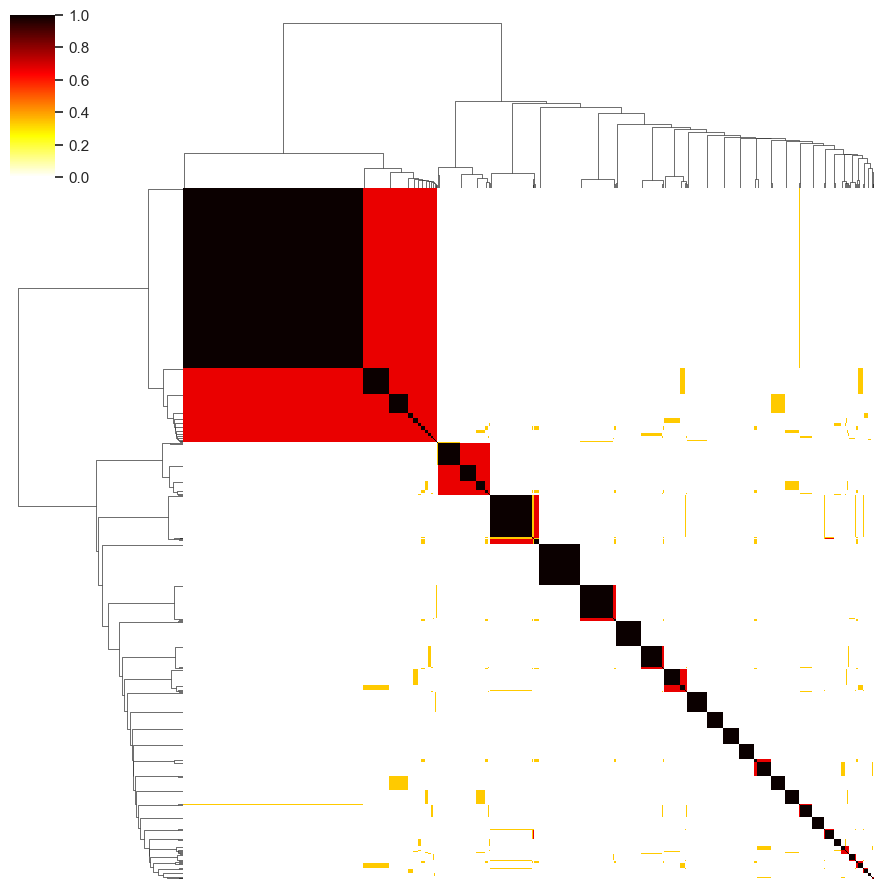

In [23]:
size = 9

#legend_TN = [patches.Patch(color=c, label=l) for l,c in mash_color_dict_31.items()] # Mash cluster for legend

sns.set(rc={'figure.facecolor':'white'})
g = sns.clustermap(
    df_consensus_matrix,
    figsize=(size,size),
    row_linkage=link,
    #row_colors=phylogroup_clst.color, # Phylogroup colors on left
    col_linkage=link,
    #col_colors=clst.color, # Mash cluster on top
    yticklabels=False,
    xticklabels=False,
    cmap='hot_r'
)

#l2=g.ax_heatmap.legend(loc='upper left', bbox_to_anchor=(1.01,0.75), handles=legend_TN, frameon=True)
#l2.set_title(title='Mash cluster',prop={'size':10})

In [24]:
# upper diagonal elements of consensus
avec = np.array([consensus_matrix[i, j] for i in range(consensus_matrix.shape[0] - 1)
                 for j in range(i + 1, consensus_matrix.shape[1])])

# consensus entries are similarities, conversion to distances
Y = 1 - avec
Z = hc.linkage(Y, method='ward')

# cophenetic correlation coefficient of a hierarchical clustering
# defined by the linkage matrix Z and matrix Y from which Z was
# generated
coph_cor, _ = cophenet(Z, Y)

coph_cor # Cophenetic correlation of consensus matrix (ideally 0.7 or higher)

0.687495082892055

In [25]:
dispersion = np.sum(4 * np.multiply(consensus_matrix - 0.5, consensus_matrix - 0.5)) / consensus_matrix.size

dispersion # Dispersion coefficient of consensus matrix

0.9298857217056746

## Consensus model 2: Reduced accessory

In [26]:
# Input matrix
X = df_acc_75.copy()

X.shape

(12220, 1317)

In [27]:
# Number of NMF runs (~3 min for 50 runs)
n_runs = 3

# Rank of NMF (Mash rank for complete strains)
rank = RANK

# Max iterations per run
max_iter = 5_000

# Initialize dictionaries to store W and H matrices
W_dict_red = {}
H_dict_red = {}

# Initialize dictionary to store NMF model
nmf_red_dict = {}

# Store model errors (becomes pandas DataFrame)
nmf_red_errors = []

# Run NMF num_runs times and store W and H matrices in dictionaries
for i in trange(n_runs):
    nmf_red = NMF(
        n_components=rank,
        init='nndsvd', # gives sparser basis matrix
        max_iter=max_iter,
        random_state=i+731
    )
    W = nmf_red.fit_transform(X) # basis matrix (gene groupings)
    H = nmf_red.components_ # coefficients matrix (strain groupings)
    W_dict_red[i] = W
    H_dict_red[i] = H
    
    X_approx = pd.DataFrame(
        np.dot(W, H),
        index=X.index,
        columns=X.columns
    )
    
    nmf_red_dict[i] = nmf_red    
    
    # Store error metrics
    entry = {}
    entry['run'] = i
    entry['rmse']  = np.sqrt(mean_squared_error(X, X_approx))
    entry['mae']  = median_absolute_error(X, X_approx)
    entry['fro'] = np.linalg.norm(X - X_approx)
    entry['ssr'] = np.square(X - X_approx).values.flatten().sum()
    
    nmf_red_errors.append(entry)

nmf_red_errors = pd.DataFrame(nmf_red_errors)

  0%|          | 0/3 [00:00<?, ?it/s]

In [28]:
# Initialize the new dictionary
conn_dict_red = {}

# Loop over each matrix in the H_dict dictionary
for key, H in H_dict_red.items():
    conn_dict_red[key] = connectivity(X, H)

In [29]:
# Consensus matrix for these runs (H matrix, default)
consensus_matrix_red = np.zeros(shape=conn_dict_red[0].shape)

for key, conn_matrix in conn_dict_red.items():
    consensus_matrix_red += conn_matrix

consensus_matrix_red /= len(conn_dict_red)

df_consensus_matrix_red = pd.DataFrame(consensus_matrix_red, index=X.columns, columns=X.columns)
df_consensus_matrix_red

,GCA_048593205.1,GCA_051016185.1,GCF_000006765.1,GCF_000014625.1,GCF_000026645.1,GCF_000168335.1,GCF_000223945.1,GCF_000223965.1,GCF_000226155.1,GCF_000271365.1,...,GCF_902172305.2,GCF_902703185.1,GCF_902703195.1,GCF_902703215.1,GCF_904866275.1,GCF_905071885.1,GCF_951691365.1,GCF_951802375.2,GCF_951805275.2,GCF_976988945.1
GCA_048593205.1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
GCA_051016185.1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GCF_000006765.1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GCF_000014625.1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GCF_000026645.1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GCF_905071885.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
GCF_951691365.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
GCF_951802375.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
GCF_951805275.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


In [30]:
# change this to get different number of clusters

# Minimum acceptable value for robust clusters = 50%
thresh = 0.75

# change this to get a different linkage (by method)
df_consensus_dist_red = 1 - df_consensus_matrix_red
link = hc.linkage(scipy.spatial.distance.squareform(df_consensus_dist_red), method='ward')

# retrieve clusters using fcluster
dist = scipy.spatial.distance.squareform(df_consensus_dist_red)

consensus_clst_red = pd.DataFrame(index=X.columns)
consensus_clst_red['cluster'] = hc.fcluster(link, thresh * dist.max(), 'distance')

In [31]:
# # Bar plot showing sizes of each consensus NMF cluster
# sns.barplot(
#     x=consensus_clst_red.cluster.value_counts().sort_index().index,
#     y=consensus_clst_red.cluster.value_counts().sort_index().values
# )

In [32]:
# Bar plot showing sizes of each consensus NMF cluster
px.bar(
    x=consensus_clst_red.cluster.value_counts().sort_index().index,
    y=consensus_clst_red.cluster.value_counts().sort_index().values
)

In [33]:
# Color each NMF cluster (default matplotlib colors)

#cm = matplotlib.colormaps.get_cmap('tab20')
cmb = matplotlib.colormaps.get_cmap('tab20b')
cmc = matplotlib.colormaps.get_cmap('tab20c')
cm_colors = cmb.colors + cmc.colors

consensus_clr_red = dict(zip(sorted(consensus_clst_red.cluster.unique()), cm_colors))
consensus_clst_red['color'] = consensus_clst_red.cluster.map(consensus_clr_red)

print('Number of colors: ', len(consensus_clr_red))
print('Number of clusters', len(consensus_clst_red.cluster.unique()))

Number of colors:  36
Number of clusters 36


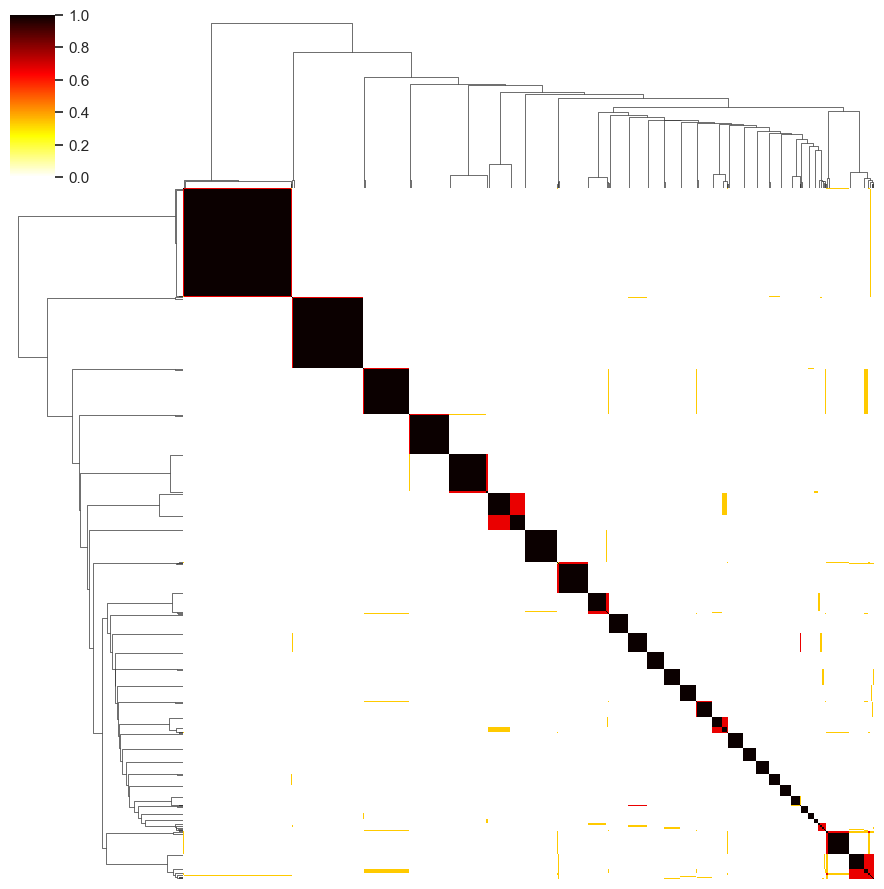

In [34]:
size = 9

#legend_TN = [patches.Patch(color=c, label=l) for l,c in mash_color_dict_31.items()] # Mash cluster for legend

sns.set(rc={'figure.facecolor':'white'})
g = sns.clustermap(
    df_consensus_matrix_red,
    figsize=(size,size),
    row_linkage=link,
    #row_colors=phylogroup_clst.color, # Phylogroup colors on left
    col_linkage=link,
    #col_colors=clst.color, # Mash cluster on top
    yticklabels=False,
    xticklabels=False,
    cmap='hot_r'
)

#l2=g.ax_heatmap.legend(loc='upper left', bbox_to_anchor=(1.01,0.85), handles=legend_TN,frameon=True)
#l2.set_title(title='Mash cluster',prop={'size':10})

In [35]:
# upper diagonal elements of consensus
avec = np.array([df_consensus_matrix_red.values[i, j] for i in range(df_consensus_matrix_red.shape[0] - 1)
                 for j in range(i + 1, df_consensus_matrix_red.shape[1])])

# consensus entries are similarities, conversion to distances
Y = 1 - avec
Z = hc.linkage(Y, method='ward')

# cophenetic correlation coefficient of a hierarchical clustering
# defined by the linkage matrix Z and matrix Y from which Z was
# generated
coph_cor_red, _ = cophenet(Z, Y)

coph_cor_red # Cophenetic correlation of reduced consensus matrix

0.6527539352609115

In [36]:
dispersion_red = np.sum(
    4 * np.multiply(
        df_consensus_matrix_red.values - 0.5,
        df_consensus_matrix_red.values - 0.5
    )
) / consensus_matrix_red.size # same size as df_consensus_matrix_red

dispersion_red # Dispersion coefficient of consensus matrix

0.9906913345787844

## Consensus model 3: Infrequent accessory

In [37]:
# Input matrix
X = df_acc_50.copy()

X.shape

(12058, 1317)

In [38]:
# Number of NMF runs (~1 min for 50 runs)
n_runs = 3

# Rank of NMF (Mash rank for complete strains)
rank = RANK

# Max iterations per run
max_iter = 5_000

# Initialize dictionaries to store W and H matrices
W_dict_min = {}
H_dict_min = {}

# Initialize dictionary to store NMF model
nmf_min_dict = {}

# Store model errors (becomes pandas DataFrame)
nmf_min_errors = []

# Run NMF num_runs times and store W and H matrices in dictionaries
for i in trange(n_runs):
    nmf_min = NMF(
        n_components=rank,
        init='nndsvd', # gives sparser basis matrix
        max_iter=max_iter,
        random_state=i+15
    )
    W = nmf_min.fit_transform(X) # basis matrix (gene groupings)
    H = nmf_min.components_ # coefficients matrix (strain groupings)
    W_dict_min[i] = W
    H_dict_min[i] = H
    
    X_approx = pd.DataFrame(
        np.dot(W, H),
        index=X.index,
        columns=X.columns
    )
    
    nmf_min_dict[i] = nmf_min
    
    # Store error metrics
    entry = {}
    entry['run'] = i
    entry['rmse']  = np.sqrt(mean_squared_error(X, X_approx))
    entry['mae']  = median_absolute_error(X, X_approx)
    entry['fro'] = np.linalg.norm(X - X_approx)
    entry['ssr'] = np.square(X - X_approx).values.flatten().sum()
    
    nmf_min_errors.append(entry)

nmf_min_errors = pd.DataFrame(nmf_min_errors)

  0%|          | 0/3 [00:00<?, ?it/s]

In [39]:
# Initialize the new dictionary
conn_dict_min = {}

# Loop over each matrix in the H_dict dictionary
for key, H in H_dict_min.items():
    conn_dict_min[key] = connectivity(X, H)

In [40]:
# Consensus matrix for these runs (H matrix, default)
consensus_matrix_min = np.zeros(shape=conn_dict_min[0].shape)

for key, conn_matrix in conn_dict_min.items():
    consensus_matrix_min += conn_matrix

consensus_matrix_min /= len(conn_dict)

df_consensus_matrix_min = pd.DataFrame(consensus_matrix_min, index=X.columns, columns=X.columns)
df_consensus_matrix_min

,GCA_048593205.1,GCA_051016185.1,GCF_000006765.1,GCF_000014625.1,GCF_000026645.1,GCF_000168335.1,GCF_000223945.1,GCF_000223965.1,GCF_000226155.1,GCF_000271365.1,...,GCF_902172305.2,GCF_902703185.1,GCF_902703195.1,GCF_902703215.1,GCF_904866275.1,GCF_905071885.1,GCF_951691365.1,GCF_951802375.2,GCF_951805275.2,GCF_976988945.1
GCA_048593205.1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
GCA_051016185.1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GCF_000006765.1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GCF_000014625.1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GCF_000026645.1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GCF_905071885.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
GCF_951691365.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
GCF_951802375.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
GCF_951805275.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


In [41]:
# change this to get different number of clusters

# Minimum acceptable value for robust clusters = 50%
thresh = 0.75

# change this to get a different linkage (by method)
df_consensus_dist_min = 1 - df_consensus_matrix_min
link = hc.linkage(scipy.spatial.distance.squareform(df_consensus_dist_min), method='ward')

# retrieve clusters using fcluster
dist = scipy.spatial.distance.squareform(df_consensus_dist_min)

consensus_clst_min = pd.DataFrame(index=X.columns)
consensus_clst_min['cluster'] = hc.fcluster(link, thresh * dist.max(), 'distance')

In [43]:
# Bar plot showing sizes of each consensus NMF cluster
px.bar(
    x=consensus_clst_min.cluster.value_counts().sort_index().index,
    y=consensus_clst_min.cluster.value_counts().sort_index().values
)

In [44]:
# Color each NMF cluster (default matplotlib colors)

#cm = matplotlib.colormaps.get_cmap('tab20')
cmb = matplotlib.colormaps.get_cmap('tab20b')
cmc = matplotlib.colormaps.get_cmap('tab20c')
cm_colors = cmb.colors + cmc.colors

consensus_clr_min = dict(zip(sorted(consensus_clst_min.cluster.unique()), cm_colors))
consensus_clst_min['color'] = consensus_clst_min.cluster.map(consensus_clr_min)

print('Number of colors: ', len(consensus_clr_min))
print('Number of clusters', len(consensus_clst_min.cluster.unique()))

Number of colors:  40
Number of clusters 57


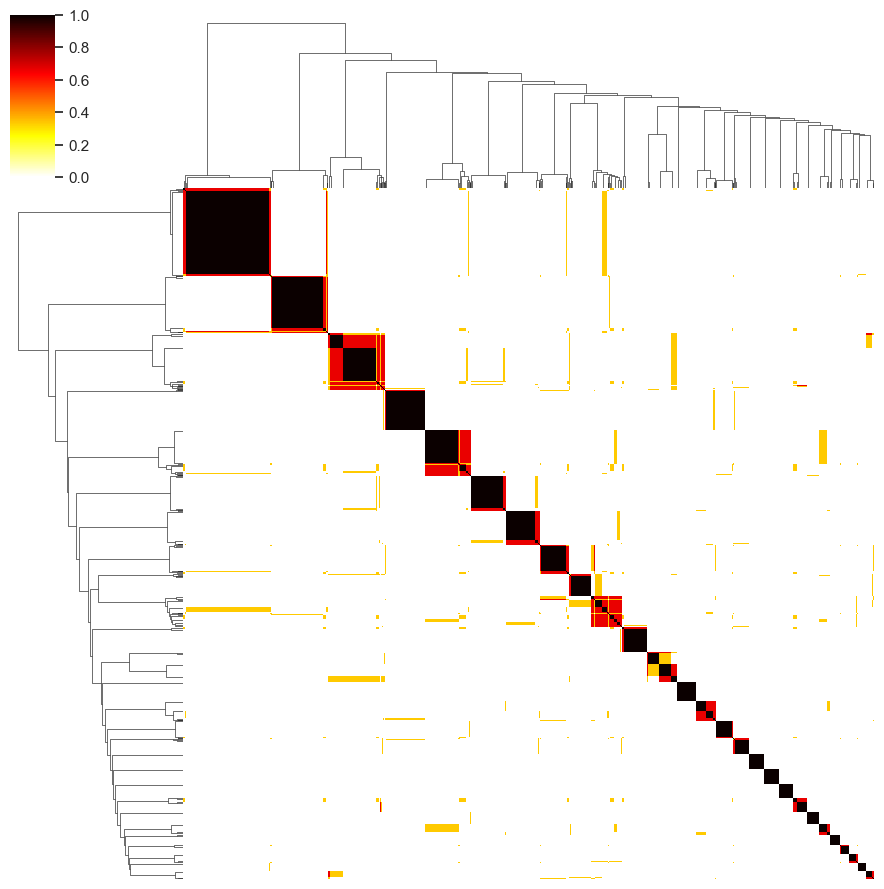

In [45]:
size = 9

#legend_TN = [patches.Patch(color=c, label=l) for l,c in mash_color_dict_31.items()] # Mash cluster for legend

sns.set(rc={'figure.facecolor':'white'})
g = sns.clustermap(
    df_consensus_matrix_min,
    figsize=(size,size),
    row_linkage=link,
    #row_colors=phylogroup_clst.color, # Phylogroup colors on left
    col_linkage=link,
    #col_colors=clst.color, # Mash cluster on top
    yticklabels=False,
    xticklabels=False,
    cmap='hot_r'
)

#l2=g.ax_heatmap.legend(loc='upper left', bbox_to_anchor=(1.01,0.85), handles=legend_TN,frameon=True)
#l2.set_title(title='Mash cluster',prop={'size':10})

In [46]:
# upper diagonal elements of consensus
avec = np.array([df_consensus_matrix_min.values[i, j] for i in range(df_consensus_matrix_min.shape[0] - 1)
                 for j in range(i + 1, df_consensus_matrix_min.shape[1])])

# consensus entries are similarities, conversion to distances
Y = 1 - avec
Z = hc.linkage(Y, method='ward')

# cophenetic correlation coefficient of a hierarchical clustering
# defined by the linkage matrix Z and matrix Y from which Z was
# generated
coph_cor_min, _ = cophenet(Z, Y)

coph_cor_min # Cophenetic correlation of reduced consensus matrix

0.6681558531941112

In [47]:
dispersion_min = np.sum(
    4 * np.multiply(
        df_consensus_matrix_min.values - 0.5,
        df_consensus_matrix_min.values - 0.5
    )
) / consensus_matrix_min.size

dispersion_min # Dispersion coefficient of consensus matrix

0.9736934368309947

## Consensus model 4: Sparse accessory

In [48]:
# Input matrix
X = df_acc_25.copy()

X

,GCA_048593205.1,GCA_051016185.1,GCF_000006765.1,GCF_000014625.1,GCF_000026645.1,GCF_000168335.1,GCF_000223945.1,GCF_000223965.1,GCF_000226155.1,GCF_000271365.1,...,GCF_902172305.2,GCF_902703185.1,GCF_902703195.1,GCF_902703215.1,GCF_904866275.1,GCF_905071885.1,GCF_951691365.1,GCF_951802375.2,GCF_951805275.2,GCF_976988945.1
Gene,,,,,,,,,,,,,,,,,,,,,
group_99,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
group_25627,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
group_25636,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
group_25779,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
group_25821,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
group_33739,0,1,1,1,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
group_32487,0,1,0,1,0,0,0,0,0,0,...,1,0,1,0,0,0,0,0,0,0
group_33327,0,1,1,1,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1


In [49]:
# Number of NMF runs (~1 min for 50 runs)
n_runs = 3

# Rank of NMF (Mash rank for complete strains)
# rank = 84

# Max iterations per run
max_iter = 5_000

# Initialize dictionaries to store W and H matrices
W_dict_sparse = {}
H_dict_sparse = {}

# Initialize dictionary to store NMF model
nmf_sparse_dict = {}

# Store model errors (becomes pandas DataFrame)
nmf_sparse_errors = []

# Run NMF num_runs times and store W and H matrices in dictionaries
for i in trange(n_runs):
    nmf_sparse = NMF(
        n_components=rank,
        init='nndsvd', # gives sparser basis matrix
        max_iter=max_iter,
        random_state=i+971
    )
    W = nmf_sparse.fit_transform(X) # basis matrix (gene groupings)
    H = nmf_sparse.components_ # coefficients matrix (strain groupings)
    W_dict_sparse[i] = W
    H_dict_sparse[i] = H
    
    X_approx = pd.DataFrame(
        np.dot(W, H),
        index=X.index,
        columns=X.columns
    )
    
    nmf_sparse_dict[i] = nmf_min
    
    # Store error metrics
    entry = {}
    entry['run'] = i
    entry['rmse']  = np.sqrt(mean_squared_error(X, X_approx))
    entry['mae']  = median_absolute_error(X, X_approx)
    entry['fro'] = np.linalg.norm(X - X_approx)
    entry['ssr'] = np.square(X - X_approx).values.flatten().sum()
    
    nmf_sparse_errors.append(entry)

nmf_sparse_errors = pd.DataFrame(nmf_min_errors)

  0%|          | 0/3 [00:00<?, ?it/s]

In [50]:
# Initialize the new dictionary
conn_dict_sparse = {}

# Loop over each matrix in the H_dict dictionary
for key, H in H_dict_sparse.items():
    conn_dict_sparse[key] = connectivity(X, H)

In [51]:
# Consensus matrix for these runs (H matrix, default)
consensus_matrix_sparse = np.zeros(shape=conn_dict_sparse[0].shape)

for key, conn_matrix in conn_dict_sparse.items():
    consensus_matrix_sparse += conn_matrix

consensus_matrix_sparse /= len(conn_dict)

df_consensus_matrix_sparse = pd.DataFrame(consensus_matrix_sparse, index=X.columns, columns=X.columns)
df_consensus_matrix_sparse

,GCA_048593205.1,GCA_051016185.1,GCF_000006765.1,GCF_000014625.1,GCF_000026645.1,GCF_000168335.1,GCF_000223945.1,GCF_000223965.1,GCF_000226155.1,GCF_000271365.1,...,GCF_902172305.2,GCF_902703185.1,GCF_902703195.1,GCF_902703215.1,GCF_904866275.1,GCF_905071885.1,GCF_951691365.1,GCF_951802375.2,GCF_951805275.2,GCF_976988945.1
GCA_048593205.1,1.000000,0.0,0.0,0.0,0.333333,0.0,0.0,0.0,1.000000,0.000000,...,1.000000,0.000000,0.0,1.000000,1.000000,0.0,0.0,0.0,0.0,0.0
GCA_051016185.1,0.000000,1.0,0.0,1.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
GCF_000006765.1,0.000000,0.0,1.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
GCF_000014625.1,0.000000,1.0,0.0,1.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
GCF_000026645.1,0.333333,0.0,0.0,0.0,1.000000,0.0,0.0,0.0,0.333333,0.333333,...,0.333333,0.000000,0.0,0.333333,0.333333,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GCF_905071885.1,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.0,0.000000,0.000000,1.0,0.0,0.0,0.0,0.0
GCF_951691365.1,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.0,0.000000,0.000000,0.0,1.0,0.0,0.0,0.0
GCF_951802375.2,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.333333,0.0,0.000000,0.000000,0.0,0.0,1.0,1.0,0.0
GCF_951805275.2,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.333333,0.0,0.000000,0.000000,0.0,0.0,1.0,1.0,0.0


In [52]:
# Minimum acceptable value for robust clusters = 50%
thresh = 0.75

# change this to get a different linkage (by method)
df_consensus_dist_sparse = 1 - df_consensus_matrix_sparse
link = hc.linkage(scipy.spatial.distance.squareform(df_consensus_dist_sparse), method='ward')

# retrieve clusters using fcluster
dist = scipy.spatial.distance.squareform(df_consensus_dist_sparse)

consensus_clst_sparse = pd.DataFrame(index=X.columns)
consensus_clst_sparse['cluster'] = hc.fcluster(link, thresh * dist.max(), 'distance')

In [54]:
# Bar plot showing sizes of each consensus NMF cluster
px.bar(
    x=consensus_clst_sparse.cluster.value_counts().sort_index().index,
    y=consensus_clst_sparse.cluster.value_counts().sort_index().values
)

In [55]:
# Color each NMF cluster (default matplotlib colors)

#cm = matplotlib.colormaps.get_cmap('tab20')
cmb = matplotlib.colormaps.get_cmap('tab20b')
cmc = matplotlib.colormaps.get_cmap('tab20c')
cm_colors = cmb.colors + cmc.colors

consensus_clr_sparse = dict(zip(sorted(consensus_clst_sparse.cluster.unique()), cm_colors))
consensus_clst_sparse['color'] = consensus_clst_sparse.cluster.map(consensus_clr_sparse)

print('Number of colors: ', len(consensus_clr_sparse))
print('Number of clusters', len(consensus_clst_sparse.cluster.unique()))

Number of colors:  40
Number of clusters 60


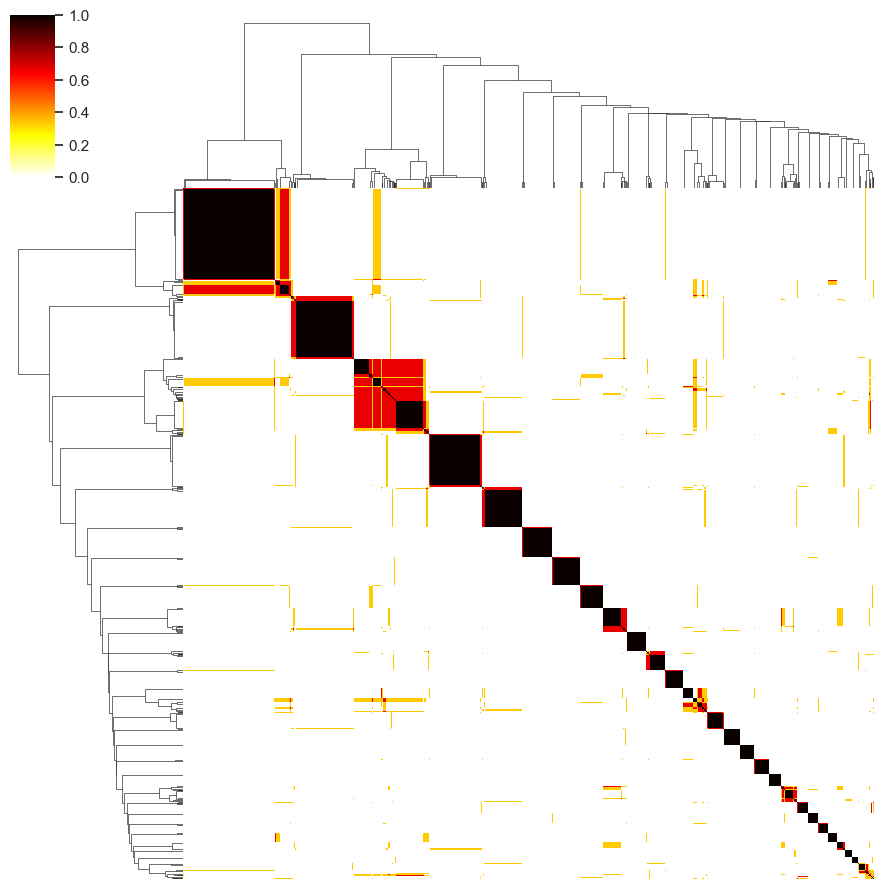

In [56]:
size = 9

#legend_TN = [patches.Patch(color=c, label=l) for l,c in mash_color_dict_31.items()] # Mash cluster for legend

sns.set(rc={'figure.facecolor':'white'})
g = sns.clustermap(
    df_consensus_matrix_sparse,
    figsize=(size,size),
    row_linkage=link,
    #row_colors=phylogroup_clst.color, # Phylogroup colors on left
    col_linkage=link,
    #col_colors=clst.color, # Mash cluster on top
    yticklabels=False,
    xticklabels=False,
    cmap='hot_r'
)

#l2=g.ax_heatmap.legend(loc='upper left', bbox_to_anchor=(1.01,0.85), handles=legend_TN,frameon=True)
#l2.set_title(title='Mash cluster',prop={'size':10})

In [57]:
# upper diagonal elements of consensus
avec = np.array([df_consensus_matrix_sparse.values[i, j] for i in range(df_consensus_matrix_sparse.shape[0] - 1)
                 for j in range(i + 1, df_consensus_matrix_sparse.shape[1])])

# consensus entries are similarities, conversion to distances
Y = 1 - avec
Z = hc.linkage(Y, method='ward')

# cophenetic correlation coefficient of a hierarchical clustering
# defined by the linkage matrix Z and matrix Y from which Z was
# generated
coph_cor_sparse, _ = cophenet(Z, Y)

coph_cor_sparse # Cophenetic correlation of reduced consensus matrix

0.6458189664040467

In [58]:
dispersion_sparse = np.sum(
    4 * np.multiply(
        df_consensus_matrix_sparse.values - 0.5,
        df_consensus_matrix_sparse.values - 0.5
    )
) / consensus_matrix_sparse.size

dispersion_sparse # Dispersion coefficient of consensus matrix

0.966274793325296

## Meta-consensus model

In [59]:
assert df_consensus_matrix.shape == df_consensus_matrix_red.shape == \
    df_consensus_matrix_min.shape == df_consensus_matrix_sparse.shape

df_consensus_matrix.shape

(1317, 1317)

In [60]:
df_meta_consensus_matrix = pd.DataFrame(
    np.zeros(df_consensus_matrix.shape),
    index=df_consensus_matrix.index,
    columns=df_consensus_matrix.columns
)

df_meta_consensus_matrix = df_consensus_matrix + df_consensus_matrix_red + \
    df_consensus_matrix_min + df_consensus_matrix_sparse

df_meta_consensus_matrix /= 4

df_meta_consensus_matrix

,GCA_048593205.1,GCA_051016185.1,GCF_000006765.1,GCF_000014625.1,GCF_000026645.1,GCF_000168335.1,GCF_000223945.1,GCF_000223965.1,GCF_000226155.1,GCF_000271365.1,...,GCF_902172305.2,GCF_902703185.1,GCF_902703195.1,GCF_902703215.1,GCF_904866275.1,GCF_905071885.1,GCF_951691365.1,GCF_951802375.2,GCF_951805275.2,GCF_976988945.1
GCA_048593205.1,1.000000,0.0,0.000000,0.0,0.083333,0.0,0.0,0.0,1.000000,0.000000,...,0.750000,0.000000,0.0,0.750000,0.750000,0.000000,0.00,0.00,0.00,0.0
GCA_051016185.1,0.000000,1.0,0.000000,1.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.00,0.00,0.00,0.0
GCF_000006765.1,0.000000,0.0,1.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.250000,0.000000,0.0,0.250000,0.250000,0.166667,0.00,0.00,0.00,0.0
GCF_000014625.1,0.000000,1.0,0.000000,1.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.00,0.00,0.00,0.0
GCF_000026645.1,0.083333,0.0,0.000000,0.0,1.000000,0.0,0.0,0.0,0.083333,0.416667,...,0.083333,0.000000,0.0,0.083333,0.083333,0.000000,0.00,0.00,0.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GCF_905071885.1,0.000000,0.0,0.166667,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.166667,0.000000,0.0,0.166667,0.166667,1.000000,0.00,0.00,0.00,0.0
GCF_951691365.1,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,1.00,0.25,0.25,0.0
GCF_951802375.2,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.083333,0.0,0.000000,0.000000,0.000000,0.25,1.00,1.00,0.0
GCF_951805275.2,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.083333,0.0,0.000000,0.000000,0.000000,0.25,1.00,1.00,0.0


In [61]:
# Minimum acceptable value for robust clusters = (75%)
thresh = 0.75

# change this to get a different linkage (by method)
df_meta_consensus_dist = 1 - df_meta_consensus_matrix
link = hc.linkage(scipy.spatial.distance.squareform(df_meta_consensus_dist), method='ward')

# retrieve clusters using fcluster
dist = scipy.spatial.distance.squareform(df_meta_consensus_dist)

meta_consensus_clst = pd.DataFrame(index=X.columns)
meta_consensus_clst['cluster'] = hc.fcluster(link, thresh * dist.max(), 'distance')

In [63]:
# Bar plot showing sizes of each meta-consensus NMF cluster
px.bar(
    x=meta_consensus_clst.cluster.value_counts().sort_index().index,
    y=meta_consensus_clst.cluster.value_counts().sort_index().values
)

In [64]:
# Color each NMF cluster (default matplotlib colors)

cm1 = matplotlib.colormaps.get_cmap('Pastel1')
cm2 = matplotlib.colormaps.get_cmap('Pastel2')
cma = matplotlib.colormaps.get_cmap('tab20')
cmb = matplotlib.colormaps.get_cmap('tab20b')
cmc = matplotlib.colormaps.get_cmap('tab20c')
cm_colors = cm1.colors + cm2.colors + cma.colors +cmb.colors + cmc.colors

meta_consensus_clr = dict(zip(sorted(meta_consensus_clst.cluster.unique()), cm_colors))
meta_consensus_clst['color'] = meta_consensus_clst.cluster.map(meta_consensus_clr)

print('Number of colors: ', len(meta_consensus_clr))
print('Number of clusters', len(meta_consensus_clst.cluster.unique()))

Number of colors:  77
Number of clusters 115


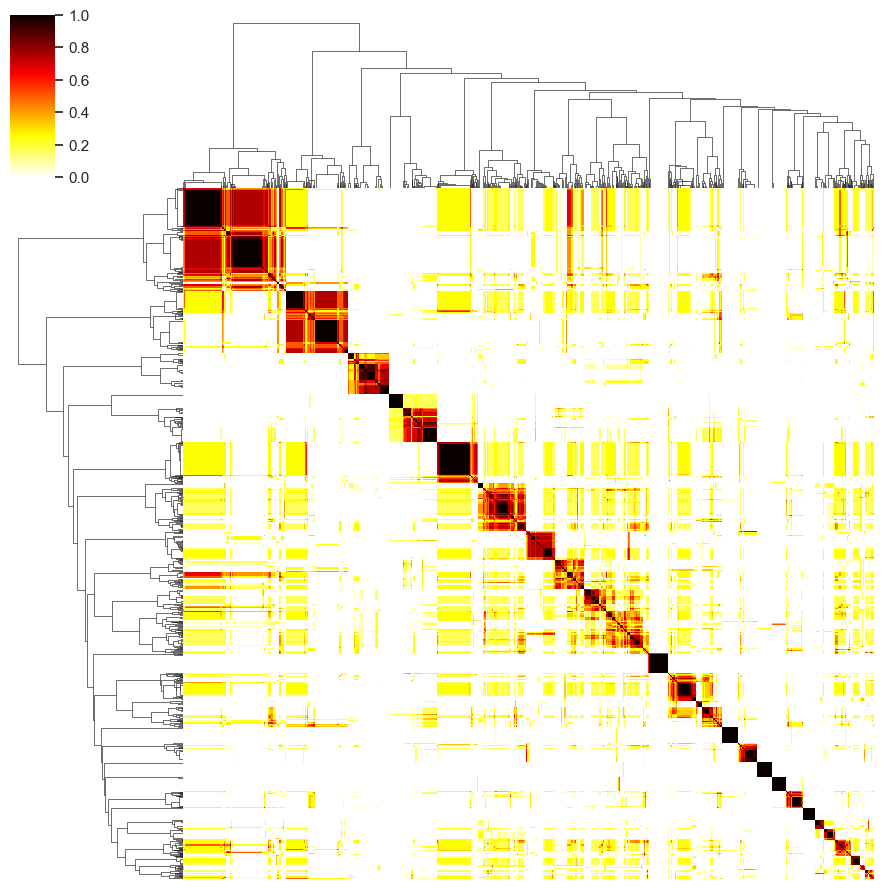

In [65]:
size = 9

#legend_TN = [patches.Patch(color=c, label=l) for l,c in mash_color_dict_31.items()] # Mash cluster for legend

sns.set(rc={'figure.facecolor':'white'})
g = sns.clustermap(
    df_meta_consensus_matrix,
    figsize=(size,size),
    row_linkage=link,
    #row_colors=phylogroup_clst.color, # Phylogroup colors on left
    col_linkage=link,
    #col_colors=clst.color, # Mash cluster on top
    yticklabels=False,
    xticklabels=False,
    cmap='hot_r'
)

#l2=g.ax_heatmap.legend(loc='upper left', bbox_to_anchor=(1.01,0.85), handles=legend_TN,frameon=True)
#l2.set_title(title='Mash cluster',prop={'size':10})

In [66]:
# upper diagonal elements of consensus
avec = np.array([df_meta_consensus_matrix.values[i, j] for i in range(df_meta_consensus_matrix.shape[0] - 1)
                 for j in range(i + 1, df_meta_consensus_matrix.shape[1])])

# consensus entries are similarities, conversion to distances
Y = 1 - avec
Z = hc.linkage(Y, method='ward')

# cophenetic correlation coefficient of a hierarchical clustering
# defined by the linkage matrix Z and matrix Y from which Z was
# generated
coph_cor_meta, _ = cophenet(Z, Y)

coph_cor_meta # Cophenetic correlation of reduced consensus matrix

0.5244360062297095

In [67]:
dispersion_meta = np.sum(
    4 * np.multiply(
        df_meta_consensus_matrix.values - 0.5,
        df_meta_consensus_matrix.values - 0.5
    )
) / df_meta_consensus_matrix.size

dispersion_meta # Dispersion coefficient of consensus matrix

0.8433395785284434

## Find best run for main model

In [68]:
df_nmf_errors.sort_values(by='Frobenius')

,SSR,Frobenius,MAE,RMSE
Run,,,,
3,197901.214453,444.860893,0.063823,0.239853
2,197901.214942,444.860894,0.063823,0.239853
1,198305.236208,445.314761,0.064307,0.240097


In [69]:
best_run = df_nmf_errors['Frobenius'].idxmin()

L = W_dict[best_run-1]
A = H_dict[best_run-1]

In [70]:
mash = metadata[metadata.genome_status=='Complete'][['genome_id','mash_cluster']].fillna(0)
mash = mash.set_index('genome_id')
mash.mash_cluster = mash.mash_cluster.apply(float)
cm = matplotlib.colormaps.get_cmap('tab20')
cmb = matplotlib.colormaps.get_cmap('tab20b')
clr = dict(zip(sorted(mash.mash_cluster.unique()), cm.colors + cmb.colors))
mash['color'] = mash.mash_cluster.map(clr)

In [71]:
# link, dist, clst = cluster_corr_dist(df_mash_corr_dist_complete, thresh=elbow_threshold)

# Color each cluster
cm = matplotlib.colormaps.get_cmap('tab20')
clr = dict(zip(sorted(mash.mash_cluster.unique()), cm.colors))
mash['color'] = mash.mash_cluster.map(clr)

print('Number of colors: ', len(clr))
print('Number of clusters', len(mash.mash_cluster.unique()))

Number of colors:  20
Number of clusters 103


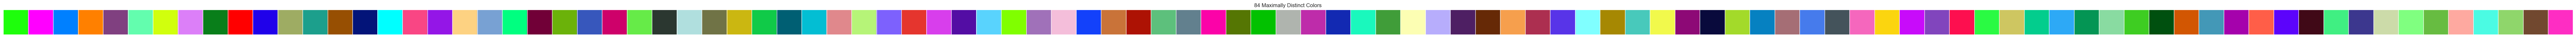

In [72]:
# expanding set of colors to 84
# !pip install distinctipy

import distinctipy
import matplotlib.colors as mcolors

cluster_labels = sorted(mash.mash_cluster.unique())
num_clusters = len(cluster_labels)

colors = distinctipy.get_colors(num_clusters)

hex_colors = [mcolors.to_hex(c) for c in colors]

clr = dict(zip(cluster_labels, hex_colors))
mash['color'] = mash.mash_cluster.map(clr)

sns.palplot(hex_colors)
plt.title("84 Maximally Distinct Colors")
plt.show()

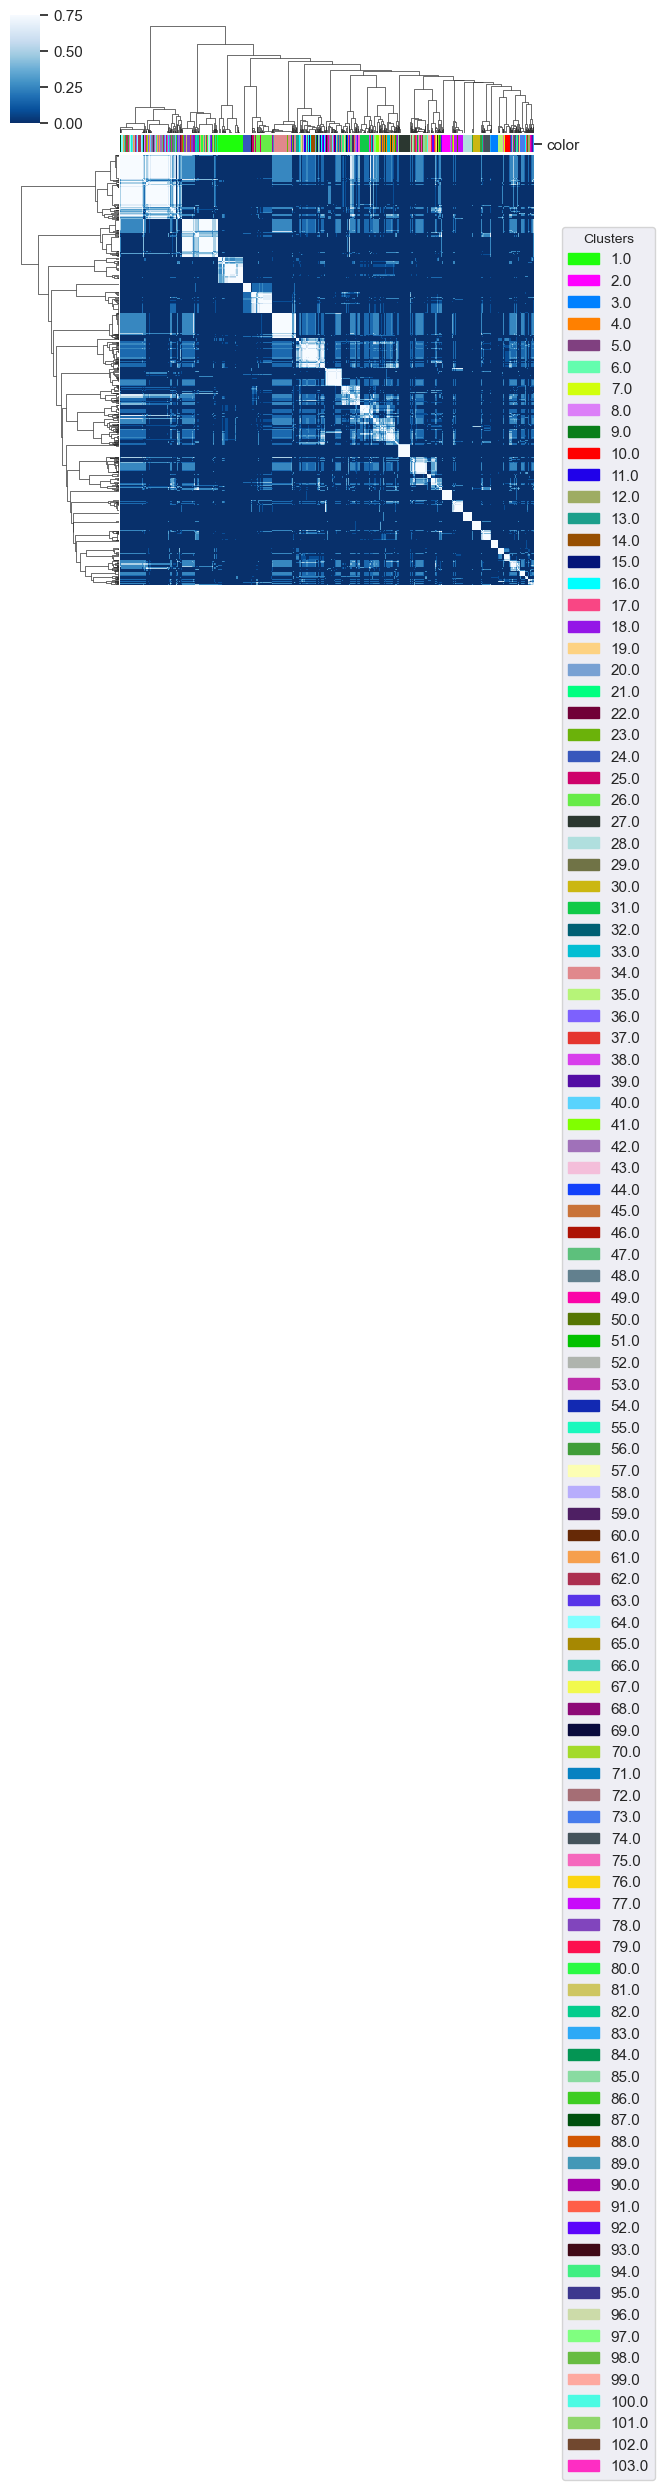

In [73]:
import matplotlib.patches as patches

size = 6

legend_TN = [patches.Patch(color=c, label=l) for l,c in clr.items()]

sns.set(rc={'figure.facecolor':'white'})
g = sns.clustermap(
    df_meta_consensus_matrix,
    figsize=(size,size),
    row_linkage=link,
    col_linkage=link,
    col_colors=mash.color,
    yticklabels=False,
    xticklabels=False,
    cmap='Blues_r',
    robust=True
)

l2=g.ax_heatmap.legend(loc='upper left', bbox_to_anchor=(1.05,0.85), handles=legend_TN,frameon=True)
l2.set_title(title='Clusters',prop={'size':10})

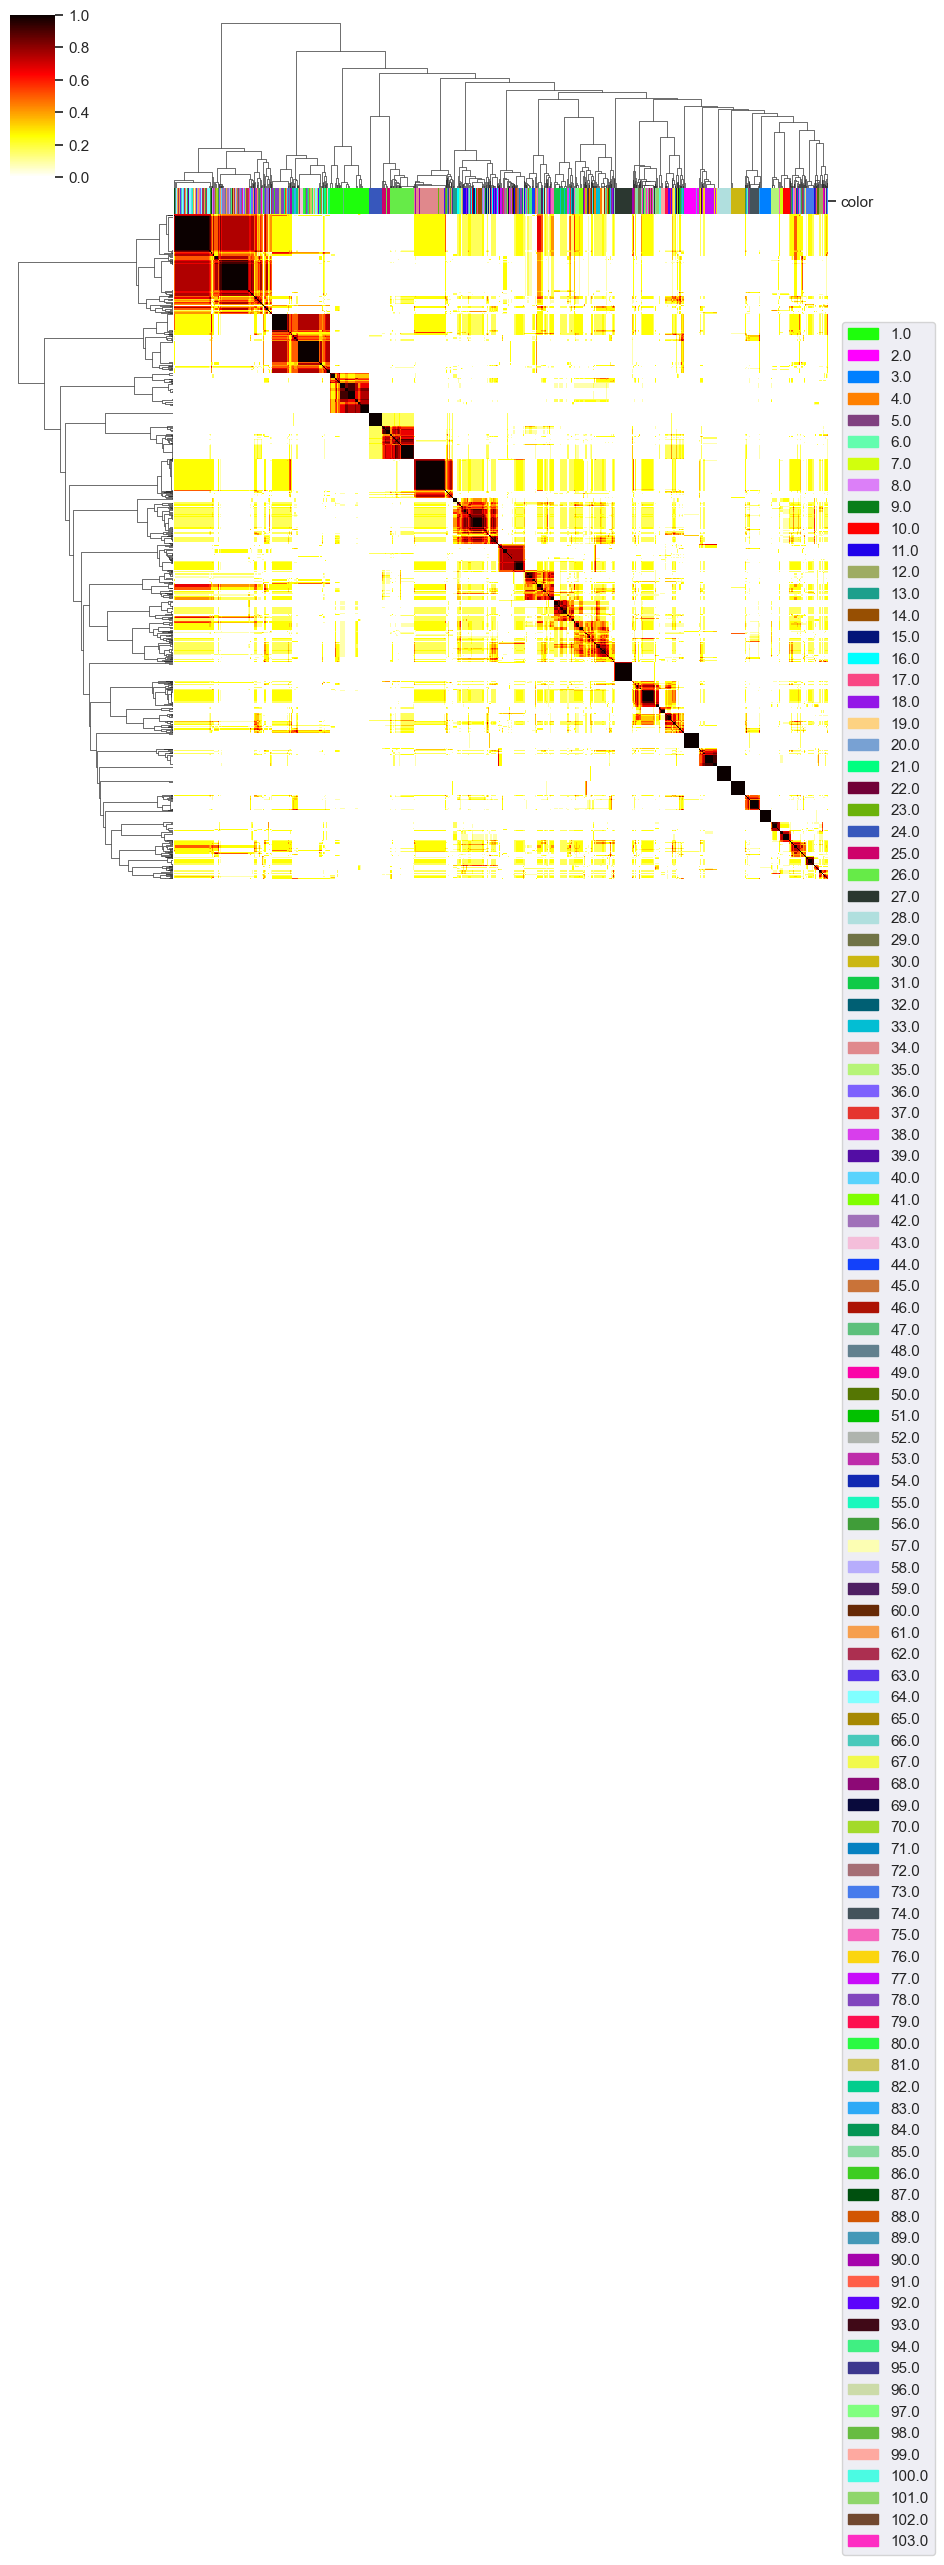

In [74]:
size = 9
import matplotlib.patches as patches

#legend_TN = [patches.Patch(color=c, label=l) for l,c in mash_color_dict_31.items()] # Mash cluster for legend

legend_TN = [patches.Patch(color=c, label=l) for l,c in clr.items()]


sns.set(rc={'figure.facecolor':'white'})
g = sns.clustermap(
    df_meta_consensus_matrix,
    figsize=(size,size),
    row_linkage=link,
    #row_colors=phylogroup_clst.color, # Phylogroup colors on left
    col_linkage=link,
    #col_colors=clst.color, # Mash cluster on top
    yticklabels=False,
    xticklabels=False,
    cmap='hot_r',
    col_colors=mash.color
)

l2=g.ax_heatmap.legend(loc='upper left', bbox_to_anchor=(1.01,0.85), handles=legend_TN,frameon=True)
#l2.set_title(title='Mash cluster',prop={'size':10})

In [113]:
mash_cluster = 1

ind = mash[mash.mash_cluster==mash_cluster].index
# df_species.loc[ind].species.value_counts()

# Save NMF outputs

In [75]:
L.to_csv('/mnt/craig/pan_phylon/P_aeruginosa/data/processed_ncbi/nmf-outputs/L.csv')
A.to_csv('/mnt/craig/pan_phylon/P_aeruginosa/data/processed_ncbi/nmf-outputs/A.csv')